In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    LassoCV,
    RidgeCV,
    LogisticRegression,
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder,
    OrdinalEncoder,
)
from sklearn.ensemble import RandomForestClassifier
from transformers.models.esm.openfold_utils.residue_constants import resname_to_idx





In [3]:
df=pd.read_csv('requests.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   operating_system          165 non-null    object 
 1   browser                   158 non-null    object 
 2   currency_code             163 non-null    object 
 3   ip_address                155 non-null    object 
 4   cpu_cores                 164 non-null    object 
 5   chipset                   195 non-null    object 
 6   session_duration_seconds  135 non-null    float64
 7   chipset_manufacturer      165 non-null    object 
 8   clicks                    162 non-null    object 
 9   suspicious_flags          195 non-null    int64  
 10  friends_count             155 non-null    float64
 11  purchases_successful      155 non-null    float64
 12  accept_cookies            181 non-null    object 
 13  is_fraudulent             185 non-null    object 
dtypes: float64

In [6]:
df.head()

,operating_system,browser,currency_code,ip_address,cpu_cores,chipset,session_duration_seconds,chipset_manufacturer,clicks,suspicious_flags,friends_count,purchases_successful,accept_cookies,is_fraudulent
0,Windows,NaN,USD,164.29.94.215,9 cpus,Intel Core i9-11900K,245.0,Intel,3-6,0,625.0,0.0,Yes,True
1,Linux,Firefox,EUR,212.114.74.220,8 cpus,Apple M2,NaN,Apple,2-7,1,157.0,0.0,Yes,True
2,Android,Brave,CHF,11.75.142.182,8 cpus,Apple M2,65.0,Apple,NaN,0,137.0,NaN,Yes,False
3,Windows,Firefox,JPY,51.49.204.153,6 cpus,Apple M2,75.0,NaN,3-8,2,841.0,0.0,Yes,True
4,Android,Opera,CHF,222.93.239.161,7 cpus,AMD Ryzen 7 5800X,148.0,AMD,NaN,0,118.0,NaN,NaN,False


In [7]:
df.drop(columns=['ip_address'],inplace=True)

In [8]:
df.isnull().sum()

operating_system            30
browser                     37
currency_code               32
cpu_cores                   31
chipset                      0
session_duration_seconds    60
chipset_manufacturer        30
clicks                      33
suspicious_flags             0
friends_count               40
purchases_successful        40
accept_cookies              14
is_fraudulent               10
dtype: int64

In [9]:
df['session_duration_seconds'].isnull().sum()

np.int64(60)

In [10]:
df.drop(columns=['session_duration_seconds'],inplace=True)

In [11]:
df=df.dropna(subset=['is_fraudulent'],axis=0)

In [12]:
df['is_fraudulent'].isnull().sum()

np.int64(0)

In [13]:
len(df['friends_count'].unique())

120

In [14]:
df.drop(columns=['friends_count'],inplace=True)

In [15]:
df.head()

,operating_system,browser,currency_code,cpu_cores,chipset,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,Windows,NaN,USD,9 cpus,Intel Core i9-11900K,Intel,3-6,0,0.0,Yes,True
1,Linux,Firefox,EUR,8 cpus,Apple M2,Apple,2-7,1,0.0,Yes,True
2,Android,Brave,CHF,8 cpus,Apple M2,Apple,NaN,0,NaN,Yes,False
3,Windows,Firefox,JPY,6 cpus,Apple M2,NaN,3-8,2,0.0,Yes,True
4,Android,Opera,CHF,7 cpus,AMD Ryzen 7 5800X,AMD,NaN,0,NaN,NaN,False


In [16]:
len(df['currency_code'].unique())

5

In [17]:
constant_imputer = SimpleImputer(strategy="most_frequent")
df[["operating_system"]] = constant_imputer.fit_transform(df[["operating_system"]])
df["operating_system"].unique()

array(['Windows', 'Linux', 'Android', 'iOS', 'macOS'], dtype=object)

<Axes: xlabel='browser'>

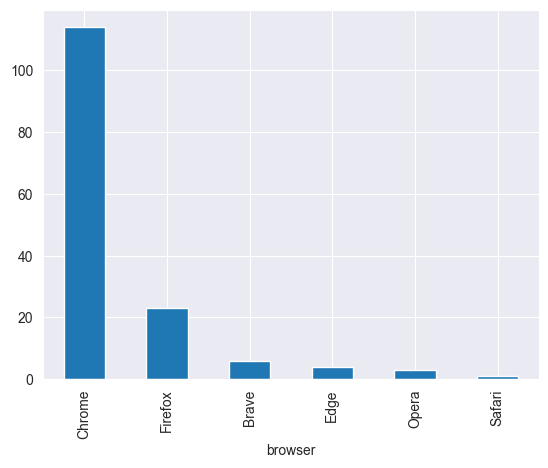

In [18]:
df['browser'].value_counts().plot.bar()

In [19]:
constant_imputer = SimpleImputer(strategy="most_frequent")
df[["browser"]] = constant_imputer.fit_transform(df[["browser"]])
df["browser"].unique()

array(['Chrome', 'Firefox', 'Brave', 'Opera', 'Safari', 'Edge'],
      dtype=object)

In [20]:
df.head()

,operating_system,browser,currency_code,cpu_cores,chipset,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,Windows,Chrome,USD,9 cpus,Intel Core i9-11900K,Intel,3-6,0,0.0,Yes,True
1,Linux,Firefox,EUR,8 cpus,Apple M2,Apple,2-7,1,0.0,Yes,True
2,Android,Brave,CHF,8 cpus,Apple M2,Apple,NaN,0,NaN,Yes,False
3,Windows,Firefox,JPY,6 cpus,Apple M2,NaN,3-8,2,0.0,Yes,True
4,Android,Opera,CHF,7 cpus,AMD Ryzen 7 5800X,AMD,NaN,0,NaN,NaN,False


In [21]:
df.isnull().sum()

operating_system         0
browser                  0
currency_code           31
cpu_cores               31
chipset                  0
chipset_manufacturer    29
clicks                  29
suspicious_flags         0
purchases_successful    39
accept_cookies          14
is_fraudulent            0
dtype: int64

In [22]:
def clean_clicks(value):
    if not pd.isna(value):
        minimum,maximum=value.split('-')
        rez=(int(minimum)+int(maximum))/2
        return rez

In [23]:
df['clicks']=df['clicks'].apply(clean_clicks)

In [24]:
df.head()

,operating_system,browser,currency_code,cpu_cores,chipset,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,Windows,Chrome,USD,9 cpus,Intel Core i9-11900K,Intel,4.5,0,0.0,Yes,True
1,Linux,Firefox,EUR,8 cpus,Apple M2,Apple,4.5,1,0.0,Yes,True
2,Android,Brave,CHF,8 cpus,Apple M2,Apple,NaN,0,NaN,Yes,False
3,Windows,Firefox,JPY,6 cpus,Apple M2,NaN,5.5,2,0.0,Yes,True
4,Android,Opera,CHF,7 cpus,AMD Ryzen 7 5800X,AMD,NaN,0,NaN,NaN,False


<Axes: xlabel='clicks', ylabel='purchases_successful'>

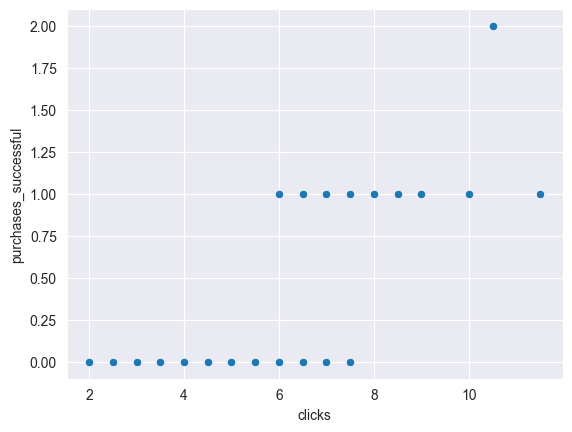

In [25]:
sns.scatterplot(x='clicks',y='purchases_successful',data=df)

<Axes: >

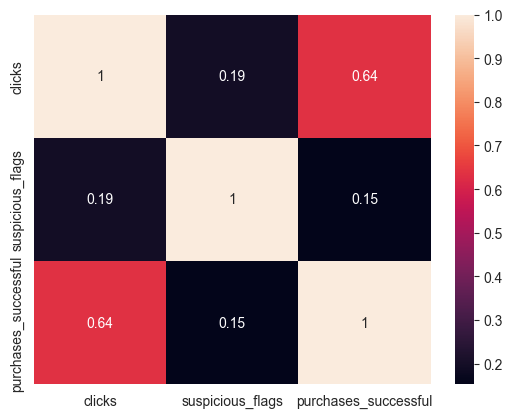

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [27]:
iterative_imputer = IterativeImputer()
imputed_data = iterative_imputer.fit_transform(df[["purchases_successful", "clicks"]])
df[["purchases_successful", "clicks"]] = imputed_data

In [28]:
df.isnull().sum()

operating_system         0
browser                  0
currency_code           31
cpu_cores               31
chipset                  0
chipset_manufacturer    29
clicks                   0
suspicious_flags         0
purchases_successful     0
accept_cookies          14
is_fraudulent            0
dtype: int64

In [29]:
chipsets=df['chipset'].values.tolist()
manus=[]
for i,chip in enumerate(chipsets):
    manus.append(chip.split(' ')[0])
df['chipset_manufacturer']=manus



In [30]:
df.head()

,operating_system,browser,currency_code,cpu_cores,chipset,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,Windows,Chrome,USD,9 cpus,Intel Core i9-11900K,Intel,4.500000,0,0.000000,Yes,True
1,Linux,Firefox,EUR,8 cpus,Apple M2,Apple,4.500000,1,0.000000,Yes,True
2,Android,Brave,CHF,8 cpus,Apple M2,Apple,5.410494,0,0.110142,Yes,False
3,Windows,Firefox,JPY,6 cpus,Apple M2,Apple,5.500000,2,0.000000,Yes,True
4,Android,Opera,CHF,7 cpus,AMD Ryzen 7 5800X,AMD,5.410494,0,0.110142,NaN,False


In [31]:
df.isnull().sum()

operating_system         0
browser                  0
currency_code           31
cpu_cores               31
chipset                  0
chipset_manufacturer     0
clicks                   0
suspicious_flags         0
purchases_successful     0
accept_cookies          14
is_fraudulent            0
dtype: int64

In [32]:
df.drop(columns=['chipset'],inplace=True)

In [33]:
df.drop(columns=['currency_code'],inplace=True)

In [34]:
df.head()

,operating_system,browser,cpu_cores,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,Windows,Chrome,9 cpus,Intel,4.500000,0,0.000000,Yes,True
1,Linux,Firefox,8 cpus,Apple,4.500000,1,0.000000,Yes,True
2,Android,Brave,8 cpus,Apple,5.410494,0,0.110142,Yes,False
3,Windows,Firefox,6 cpus,Apple,5.500000,2,0.000000,Yes,True
4,Android,Opera,7 cpus,AMD,5.410494,0,0.110142,NaN,False


In [35]:
def preprocess_cores(value):
    if not pd.isna(value):
        cor=value.split(' ')[0]
        return int(cor)
df['cpu_cores']=df['cpu_cores'].apply(preprocess_cores)


In [36]:
df['cpu_cores'].value_counts()

cpu_cores
8.0     54
9.0     38
7.0     26
6.0     14
10.0    10
5.0      5
11.0     4
4.0      3
Name: count, dtype: int64

In [37]:
def impute_cookies(value):
    if pd.isna(value):
        return 0
    return value

In [38]:
df['accept_cookies']=df['accept_cookies'].apply(impute_cookies)

In [39]:
df.isnull().sum()

operating_system         0
browser                  0
cpu_cores               31
chipset_manufacturer     0
clicks                   0
suspicious_flags         0
purchases_successful     0
accept_cookies           0
is_fraudulent            0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185 entries, 0 to 194
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   operating_system      185 non-null    object 
 1   browser               185 non-null    object 
 2   cpu_cores             154 non-null    float64
 3   chipset_manufacturer  185 non-null    object 
 4   clicks                185 non-null    float64
 5   suspicious_flags      185 non-null    int64  
 6   purchases_successful  185 non-null    float64
 7   accept_cookies        185 non-null    object 
 8   is_fraudulent         185 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 14.5+ KB


In [41]:
label_encoder=LabelEncoder()
encoded_values=label_encoder.fit_transform(df['operating_system'])
df['operating_system']=encoded_values
df.head()

,operating_system,browser,cpu_cores,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,2,Chrome,9.0,Intel,4.500000,0,0.000000,Yes,True
1,1,Firefox,8.0,Apple,4.500000,1,0.000000,Yes,True
2,0,Brave,8.0,Apple,5.410494,0,0.110142,Yes,False
3,2,Firefox,6.0,Apple,5.500000,2,0.000000,Yes,True
4,0,Opera,7.0,AMD,5.410494,0,0.110142,0,False


In [42]:
label_encoder=LabelEncoder()
encoded_values=label_encoder.fit_transform(df['browser'])
df['browser']=encoded_values

In [43]:
label_encoder=LabelEncoder()
encoded_values=label_encoder.fit_transform(df['chipset_manufacturer'])
df['chipset_manufacturer']=encoded_values

In [44]:
df['accept_cookies']=df['accept_cookies'].apply(lambda x: 1 if x=='Yes' else 0)

In [45]:
df.head()

,operating_system,browser,cpu_cores,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,2,1,9.0,2,4.500000,0,0.000000,1,True
1,1,3,8.0,1,4.500000,1,0.000000,1,True
2,0,0,8.0,1,5.410494,0,0.110142,1,False
3,2,3,6.0,1,5.500000,2,0.000000,1,True
4,0,4,7.0,0,5.410494,0,0.110142,0,False


In [46]:
df['is_fraudulent']=df['is_fraudulent'].apply(lambda x: 1 if x==True else 0)

In [47]:
df.head()

,operating_system,browser,cpu_cores,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,2,1,9.0,2,4.500000,0,0.000000,1,1
1,1,3,8.0,1,4.500000,1,0.000000,1,1
2,0,0,8.0,1,5.410494,0,0.110142,1,0
3,2,3,6.0,1,5.500000,2,0.000000,1,1
4,0,4,7.0,0,5.410494,0,0.110142,0,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185 entries, 0 to 194
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   operating_system      185 non-null    int64  
 1   browser               185 non-null    int64  
 2   cpu_cores             154 non-null    float64
 3   chipset_manufacturer  185 non-null    int64  
 4   clicks                185 non-null    float64
 5   suspicious_flags      185 non-null    int64  
 6   purchases_successful  185 non-null    float64
 7   accept_cookies        185 non-null    int64  
 8   is_fraudulent         185 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 14.5 KB


In [49]:
df.head()

,operating_system,browser,cpu_cores,chipset_manufacturer,clicks,suspicious_flags,purchases_successful,accept_cookies,is_fraudulent
0,2,1,9.0,2,4.500000,0,0.000000,1,1
1,1,3,8.0,1,4.500000,1,0.000000,1,1
2,0,0,8.0,1,5.410494,0,0.110142,1,0
3,2,3,6.0,1,5.500000,2,0.000000,1,1
4,0,4,7.0,0,5.410494,0,0.110142,0,0


In [50]:
simple_imputer=SimpleImputer(strategy='median')
df[["cpu_cores"]] = simple_imputer.fit_transform(df[["cpu_cores"]])[0]

In [51]:
X, y = df.drop(columns=['is_fraudulent']), df['is_fraudulent']

In [52]:
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(train_x, train_y)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
pred_y = model.predict(test_x)

In [55]:
print(f"Accuracy: {accuracy_score(test_y, pred_y)}")
print(f"Precision: {precision_score(test_y, pred_y)}")
print(f"Recall: {recall_score(test_y, pred_y)}")
print(f"F1-Score: {f1_score(test_y, pred_y)}")

Accuracy: 0.6216216216216216
Precision: 0.25
Recall: 0.2
F1-Score: 0.2222222222222222


In [56]:
target_0=df[df['is_fraudulent']==0].sample(50)
target_1=df[df['is_fraudulent']==1]

In [57]:
new_df=pd.concat([target_0,target_1],ignore_index=True)
df=new_df.sample(len(new_df))

In [58]:
X, y = df.drop(columns=['is_fraudulent']), df['is_fraudulent']
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(train_X, train_y)
pred_y = model.predict(test_X)

In [59]:
print(f"Accuracy: {accuracy_score(test_y, pred_y)}")
print(f"Precision: {precision_score(test_y, pred_y)}")
print(f"Recall: {recall_score(test_y, pred_y)}")
print(f"F1-Score: {f1_score(test_y, pred_y)}")

Accuracy: 0.3684210526315789
Precision: 0.3333333333333333
Recall: 0.2
F1-Score: 0.25
